🧠 正在根据预测地图训练避障决策策略...
Episode 10, Reward: 38960.00, Epsilon: 0.01
Episode 20, Reward: 39350.00, Epsilon: 0.01
Episode 30, Reward: 39230.00, Epsilon: 0.01
Episode 40, Reward: 39410.00, Epsilon: 0.01
Episode 50, Reward: 39200.00, Epsilon: 0.01

📊 决策评估完成！避障成功率: 99.75%


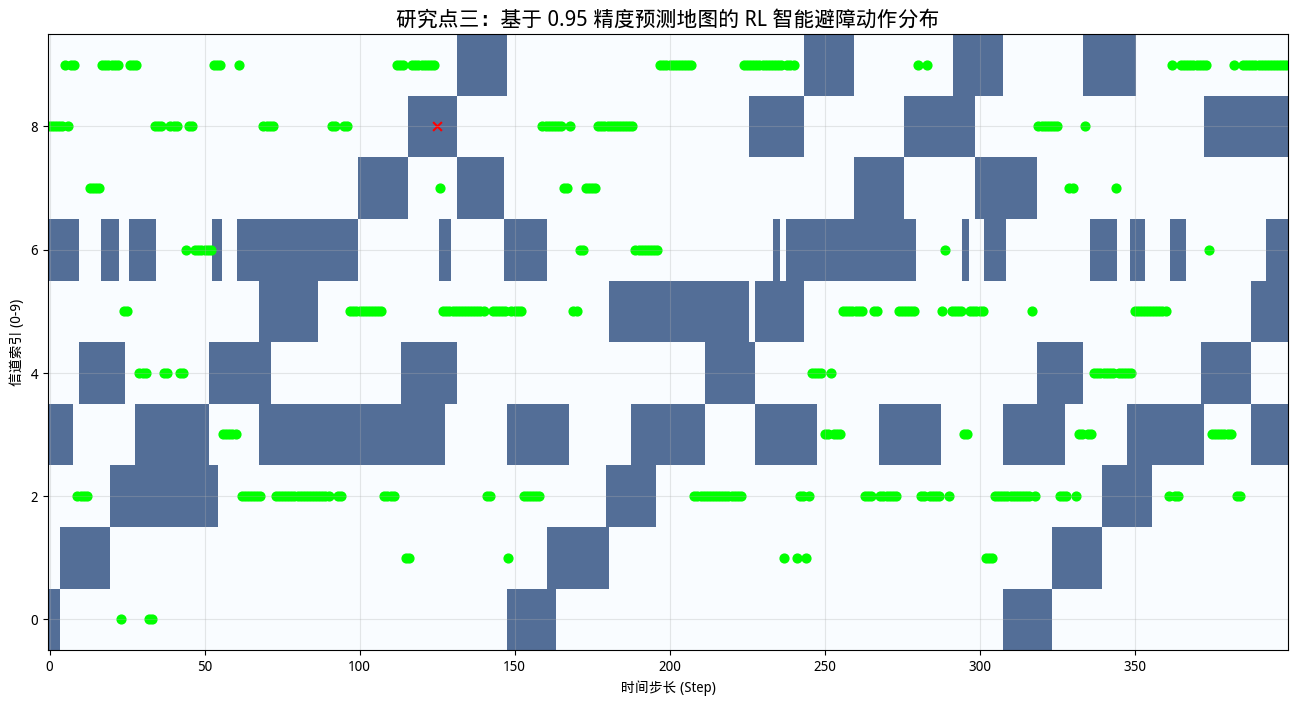

In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from tqdm import tqdm
import os

# ---------------------- 1. 环境配置 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ---------------------- 2. 强化学习环境定义 ----------------------
class SatelliteEnv:
    """
    基于 Transformer 预测地图的卫星决策环境
    """
    def __init__(self, pred_data, truth_data):
        self.pred_map = pred_data   # Transformer 输出的预测矩阵 (N, 10, 10)
        self.truth_map = truth_data # 对应的干扰真值轨迹 (N, 10, 10)
        self.num_channels = 10
        self.max_steps = len(pred_data)
        self.current_step = 0

    def reset(self):
        self.current_step = 0
        # 状态定义：Transformer 预测的未来 0.5s 的信道占用概率矩阵
        state = self.pred_map[self.current_step] 
        return state

    def step(self, action):
        """
        action: RL 选择的信道索引 (0-9)
        """
        # 验证决策结果：在未来第 1 个步长是否发生碰撞
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        
        # 奖励设计 (Reward Shaping)
        if is_collision:
            reward = -20.0  # 碰撞重罚
        else:
            reward = 10.0   # 成功避障奖励
            
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self.pred_map[self.current_step] if not done else np.zeros((10, 10))
        return next_state, reward, done, is_collision

# ---------------------- 3. DQN 决策智能体架构 ----------------------
class QNetwork(nn.Module):
    def __init__(self, input_dim=100, output_dim=10):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim) # 输出 10 个信道的 Q 值
        )
    def forward(self, x):
        return self.net(x)

class DQNAgent:
    def __init__(self, state_dim=100, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-3)
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(10)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        return torch.argmax(self.q_net(state)).item()

    def train(self, batch_size=64):
        if len(self.memory) < batch_size: return
        batch = random.sample(self.memory, batch_size)
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        curr_q = self.q_net(states).gather(1, actions.unsqueeze(1))
        next_q = self.target_net(next_states).max(1)[0].detach()
        target_q = rewards + (1 - dones) * self.gamma * next_q
        
        loss = nn.MSELoss()(curr_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ---------------------- 4. 训练与决策执行 ----------------------
def main_rl_decision():
    # A. 加载 Transformer 的预测结果
    PRED_PATH = "/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_predict_results_final_evaluated.h5" 
    if not os.path.exists(PRED_PATH):
        print("❌ 未找到预测文件，请确保研究点二已保存结果！")
        return

    with h5py.File(PRED_PATH, 'r') as f:
        pred_maps = f['predicted_situations'][:] # (N, 10, 10)
        truth_maps = f['ground_truth_situations'][:] # (N, 10, 10)

    env = SatelliteEnv(pred_maps, truth_maps)
    agent = DQNAgent()
    
    # B. 训练决策智能体
    print("🧠 正在根据预测地图训练避障决策策略...")
    episodes = 50
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        while True:
            action = agent.choose_action(state)
            next_state, reward, done, collision = env.step(action)
            agent.memory.append((state, action, reward, next_state, done))
            agent.train()
            state = next_state
            total_reward += reward
            if done: break
        if (ep+1) % 10 == 0:
            agent.target_net.load_state_dict(agent.q_net.state_dict())
            print(f"Episode {ep+1}, Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

    # C. 最终决策可视化对比
    visualize_decisions(env, agent)

# ---------------------- 5. 决策可视化大图 ----------------------
def visualize_decisions(env, agent):
    state = env.reset()
    actions = []
    collisions = []
    
    # 执行一次完整的生存测试
    for _ in range(min(400, env.max_steps)):
        action = agent.choose_action(state)
        next_state, _, _, collision = env.step(action)
        actions.append(action)
        collisions.append(collision)
        state = next_state

    plt.figure(figsize=(16, 8))
    
    # 绘制干扰底图 (真值)
    truth_stream = env.truth_map[:len(actions), 0, :].T
    plt.imshow(truth_stream, aspect='auto', cmap='Blues', origin='lower', alpha=0.7)
    
    # 绘制决策动作
    steps = np.arange(len(actions))
    for i in range(len(actions)):
        marker = 'x' if collisions[i] else 'o'
        color = 'red' if collisions[i] else 'lime'
        plt.scatter(steps[i], actions[i], color=color, marker=marker, s=40, 
                    label='避障决策' if i == 0 else "")

    plt.title("研究点三：基于 0.95 精度预测地图的 RL 智能避障动作分布", fontsize=15)
    plt.ylabel("信道索引 (0-9)")
    plt.xlabel("时间步长 (Step)")
    plt.grid(True, alpha=0.3)
    
    success_rate = (1 - sum(collisions)/len(collisions)) * 100
    print(f"\n📊 决策评估完成！避障成功率: {success_rate:.2f}%")
    plt.show()

if __name__ == "__main__":
    main_rl_decision()